# EDA - Dataset Wine (sklearn)

## Importando pacotes e o dataset

In [12]:
import pandas as pd
from sklearn.datasets import load_wine
wine_data = load_wine()
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [13]:

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Olhando nossas features fica claro que devemos padrozinar antes de aplicar o PCA. Olhando a feature **proline** vemos que o desvio padrão está na casa de 315,o que faz com que a variância seja aproximadamente 99mil. Comparado com magnésio, o segundo colocado em variância, é um valor 500 vezes maior, e levando em conta o resto do dataset estamos falando de quase 15mil vezes maior. 

O primeiro componente principal ficaria quase colinear ao eixo do proline, e ignoraria as outras 12 features. 

## Aplicando PCA em nosso dataset

### Importando alguns pacotes

In [14]:
import numpy as np 
from sklearn.preprocessing import StandardScaler
import sys
import os
sys.path.append('../src')
import pca
import matplotlib.pyplot as plt
import seaborn as sns


### Comparando a função Normalize vs StandarScaler

In [17]:

X = wine_data.data
Xn, mean, std = pca.normalize(X)
Xn_sk = StandardScaler().fit_transform(X)

np.allclose(Xn, Xn_sk)

False

Aqui vemos que os valores de Xn (função normalize) e Xn_sk (StandardScaler) não batem. Isso se deve ao fato que a funçãop normalize usa ddof = 1, ou seja, o desvio padrão é dividido por n-1, enquanto a StandarScaler usa ddof = 0 (divide por n)

In [18]:
comp = np.std(X, axis=0, ddof=1) / np.std(X, axis=0, ddof=0)
comp

array([1.00282088, 1.00282088, 1.00282088, 1.00282088, 1.00282088,
       1.00282088, 1.00282088, 1.00282088, 1.00282088, 1.00282088,
       1.00282088, 1.00282088, 1.00282088])

Fazendo a comparação vemos que usando desvido padrão com n-1 com n, resulta em uma razão constante (vetor todo com valores aproximadamente igual a 1.0028). 
Assim, se pegarmos o valor do standarscaler e multiplicar pela raiz de (n-1)/n chegaremos no valor calculado pela normalize

In [19]:
n = X.shape[0]

np.allclose(Xn_sk * np.sqrt((n-1)/n), Xn)

True

## Calculando Variância Explicada e Cumulativa

In [20]:
score, eig_vals, components, mean, std = pca.PCA(X, num_components = 13)
explained = eig_vals / eig_vals.sum()
cumulative = explained.cumsum(axis = 0)


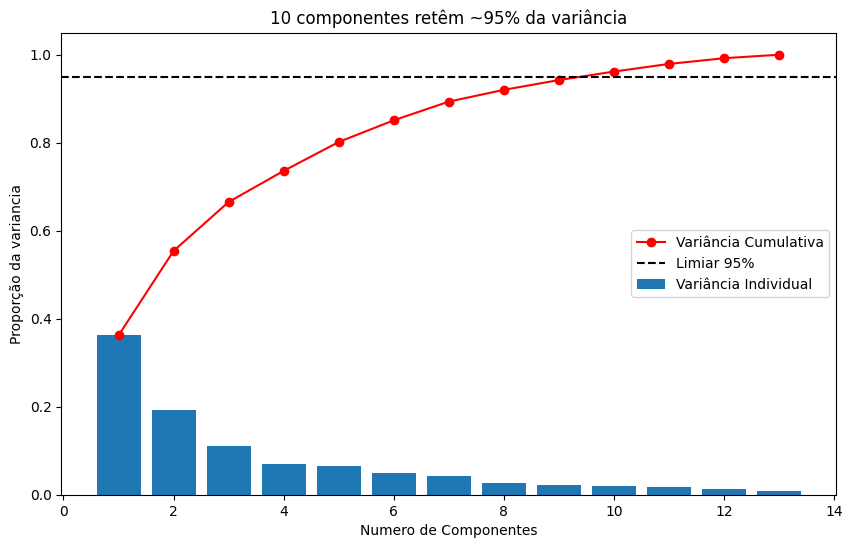

In [61]:
plt.figure(figsize=(10,6))
gra = plt.bar(range(1,14), explained, label='Variância Individual')
line = plt.plot(range(1,14), cumulative, color='red', marker='o',label='Variância Cumulativa')
axh = plt.axhline(0.95, color='black', linestyle='--', label='Limiar 95%')
plt.xlabel('Numero de Componentes')
plt.ylabel('Proporção da variancia')
plt.title('10 componentes retêm ~95% da variância')
plt.legend()
plt.savefig('../assets/variancia_explicada.png', dpi=150, bbox_inches='tight')
plt.show()

As barras mostram quanta variância cada componente principal captura sozinho; a linha vermelha é o acumulado. Fica claro o "cotovelo": o 1º componente sozinho concentra 36,2% da variância, e os primeiros poucos já carregam a maior parte da informação — a contribuição despenca rápido nos últimos.

A tracejada em 95% funciona como régua de corte. A curva acumulada cruza esse limiar no 10º componente. Ou seja: podemos reduzir de 13 features para 10 componentes principais mantendo 95% da variância e abrindo mão de só 5%.

Vale reforçar o conceito: não estou "escolhendo 10 colunas boas e jogando 3 fora". Cada componente é uma combinação linear de todas as 13 features — um eixo novo, rotacionado. Reduzindo a dimensão do espaço, não o número de variáveis originais que participam.

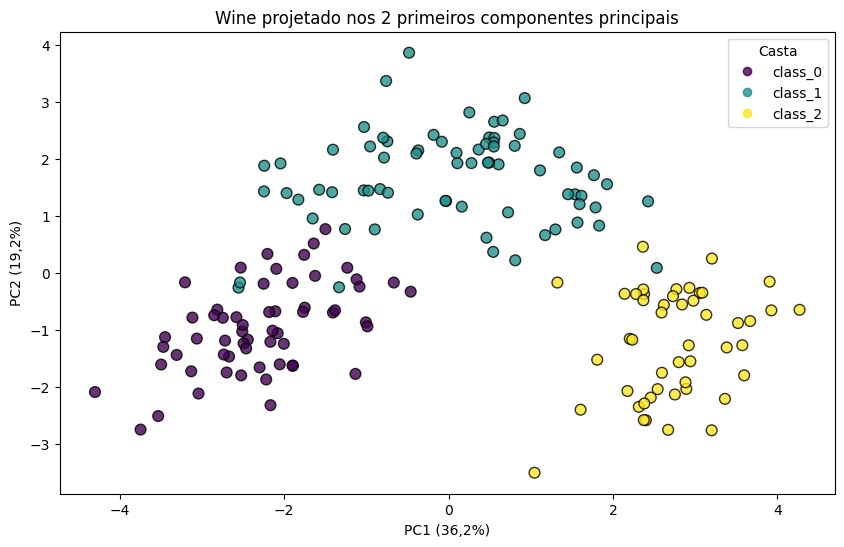

In [62]:
x = score[:, 0]
y = score[:, 1]
c = wine_data.target

plt.figure(figsize=(10,6))
sc = plt.scatter(x,y,c=c, alpha=0.8, cmap='viridis', edgecolors='k', s=60)
plt.xlabel('PC1 (36,2%)')
plt.ylabel('PC2 (19,2%)')
plt.title('Wine projetado nos 2 primeiros componentes principais')

handles, _ = sc.legend_elements()
plt.legend(handles, wine_data.target_names, title='Casta')
plt.savefig('../assets/scatter_pcs.png', dpi=150, bbox_inches='tight')
plt.show()

O que os 2 primeiros componentes revelam

Cada ponto é um vinho projetado nos dois primeiros componentes principais — juntos eles seguram uns 55% da variância (36% + 19%). Só colori por casta depois de plotar, pra ver se aparecia algum padrão.

E apareceu: as três castas caem em grupos bem definidos, com pouca mistura nas bordas. Com 2 eixos de 13 já dá pra distinguir as classes.

O que eu acho mais interessante aqui é que o PCA nunca viu os rótulos — ele só olhou a variância das features. Se mesmo assim as castas se separam, é porque a diferença entre elas já era a maior fonte de variação nos dados: vinhos de castas diferentes têm composição sistematicamente distinta, e isso vira variância que o PCA captura primeiro.

Mas não dá pra vender como mágica. Funcionou porque, no Wine, a variação entre castas é maior que a variação dentro de cada uma. Se a maior variância estivesse em outra coisa — ruído, uma feature fora de escala — o PC1 apontaria pra lá e o gráfico seria uma nuvem sem grupos. Se o objetivo fosse separar classes de propósito, a ferramenta certa seria LDA, que usa os rótulos. Aqui, a separação foi um efeito colateral feliz da estrutura dos dados.